#Menghubungkan dengan google collab

In [41]:
from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/MyDrive/praktikum_ml/praktikum11"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Import library

In [42]:
!pip install folium geopandas contextily plotly shapely

In [43]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import folium
from folium.plugins import HeatMap

import geopandas as gpd
import contextily as ctx
from mpl_toolkits.axes_grid1 import make_axes_locatable

from shapely.geometry import Point

from scipy.stats import shapiro

from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import plotly.express as px

#Load Dataset Gempa Bumi

In [44]:
df = pd.read_csv(path + "/data/earthquake_dataset.csv")

In [45]:
print(f"Jumlah data: {len(df)}")

Jumlah data: 16944


In [46]:
print(f"\nKolom yang terdapat pada dataset:")
print(df.columns.tolist())


Kolom yang terdapat pada dataset:
['Date', 'Time (UTC)', 'City', 'Country', 'Latitude', 'Longitude', 'Earthquake Magnitude', 'Depth (km)', 'Impact Score']


In [47]:
df

,Date,Time (UTC),City,Country,Latitude,Longitude,Earthquake Magnitude,Depth (km),Impact Score
0,2025-03-15,16:28:36,55 km NNW of Finschhafen,Papua New Guinea,-6.1233,147.5932,5.1,59.033,400
1,2025-03-15,03:19:27,5 km ESE of San Miguel Achiutla,Mexico,17.2871,-97.4400,5.6,63.551,503
2,2025-03-14,23:42:35,South Sandwich Islands region,South Sandwich Islands region,-55.7385,-27.1122,6.0,35.379,554
3,2025-03-14,19:37:15,15 km NNE of Lesina,Italy,41.9788,15.4490,5.0,8.742,389
4,2025-03-14,11:13:32,229 km N of Palu,Indonesia,1.1364,120.2317,5.4,26.072,449
...,...,...,...,...,...,...,...,...,...
16939,2015-03-19,10:05:59,163 km NW of Ternate,Indonesia,1.9433,126.4571,5.4,31.540,449
16940,2015-03-19,08:34:16,100 km NW of Talcahuano,Chile,-36.0228,-73.8197,5.2,3.860,416
16941,2015-03-19,03:49:23,South Sandwich Islands region,South Sandwich Islands region,-55.3910,-28.3497,5.0,28.900,385
16942,2015-03-19,03:15:22,218 km ENE of Petropavlovsk-Kamchatsky,Russia,53.5155,161.8237,5.2,13.700,416


#Data Cleaning (Pembersihan Data)

##Cek Missing Value dan Data Duplikat

In [48]:
df.isnull().sum()

,0
Date,0
Time (UTC),0
City,0
Country,0
Latitude,0
Longitude,0
Earthquake Magnitude,0
Depth (km),0
Impact Score,0


In [49]:
df.duplicated().sum()

np.int64(0)

##Menampilkan statistika deskriptif dari dataset

In [50]:
df.describe()

,Latitude,Longitude,Earthquake Magnitude,Depth (km),Impact Score
count,16944.000000,16944.000000,16944.000000,16944.000000,16944.00000
mean,-3.207032,31.839994,5.333485,53.202267,455.21636
std,30.580708,123.926484,0.404258,104.093974,137.23604
min,-69.773900,-179.989700,5.000000,-1.010000,385.00000
25%,-22.935575,-74.503150,5.100000,10.000000,400.00000
50%,-5.812300,87.378300,5.200000,11.892500,416.00000
75%,18.424575,142.010050,5.500000,45.557750,465.00000
max,87.386000,179.998100,8.300000,670.810000,2910.00000


#Filterisasi hanya gempa di Indonesia

In [51]:
df_id = df[df["Country"] == "Indonesia"].copy()
df_id


,Date,Time (UTC),City,Country,Latitude,Longitude,Earthquake Magnitude,Depth (km),Impact Score
4,2025-03-14,11:13:32,229 km N of Palu,Indonesia,1.1364,120.2317,5.4,26.072,449
27,2025-03-07,12:42:49,69 km W of Banda Aceh,Indonesia,5.4554,94.7104,5.4,73.061,449
29,2025-03-07,08:34:03,80 km E of Masamba,Indonesia,-2.4909,121.0498,5.0,10.000,386
43,2025-03-02,18:42:10,61 km ESE of Masohi,Indonesia,-3.5255,129.4706,5.3,41.306,432
52,2025-02-28,21:58:38,231 km W of Tual,Indonesia,-6.0063,130.7006,5.5,126.000,466
...,...,...,...,...,...,...,...,...,...
16911,2015-03-27,13:56:24,"139 km E of Laikit, Laikit II (Dimembe)",Indonesia,1.4552,126.2305,5.2,52.080,416
16917,2015-03-24,14:50:30,158 km WNW of Tobelo,Indonesia,2.0551,126.6242,5.2,63.480,416
16920,2015-03-23,15:48:03,72 km S of Tondano,Indonesia,0.6528,124.8816,5.2,53.240,416
16928,2015-03-21,19:46:30,218 km NNW of Tobelo,Indonesia,3.5898,127.3472,5.2,40.140,416


In [52]:
df_id.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1743 entries, 4 to 16939
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  1743 non-null   object 
 1   Time (UTC)            1743 non-null   object 
 2   City                  1743 non-null   object 
 3   Country               1743 non-null   object 
 4   Latitude              1743 non-null   float64
 5   Longitude             1743 non-null   float64
 6   Earthquake Magnitude  1743 non-null   float64
 7   Depth (km)            1743 non-null   float64
 8   Impact Score          1743 non-null   int64  
dtypes: float64(4), int64(1), object(4)
memory usage: 200.7+ KB


In [53]:
df_id.describe()

,Latitude,Longitude,Earthquake Magnitude,Depth (km),Impact Score
count,1743.000000,1743.000000,1743.000000,1743.000000,1743.000000
mean,-2.513452,118.856397,5.291452,55.384232,437.931153
std,4.342896,13.269972,0.373338,90.574911,90.905351
min,-11.626300,92.971800,5.000000,4.000000,385.000000
25%,-6.099050,105.375050,5.000000,10.000000,385.000000
50%,-2.598000,123.450300,5.200000,31.260000,416.000000
75%,1.016000,128.152150,5.400000,58.385000,449.000000
max,8.351000,140.893500,7.800000,652.530000,2033.000000


#Exploratory Data Analysis (EDA)

##Visualisasi Heatmap Sebaran Gempa

In [54]:
m = folium.Map(location=[-2, 118], zoom_start=4)

heat_data = df_id[["Latitude", "Longitude", "Impact Score"]].values.tolist()

HeatMap(heat_data, radius=6, blur=5).add_to(m)

m


##Peta Sebaran Magnitudo Gempa dengan Basemap

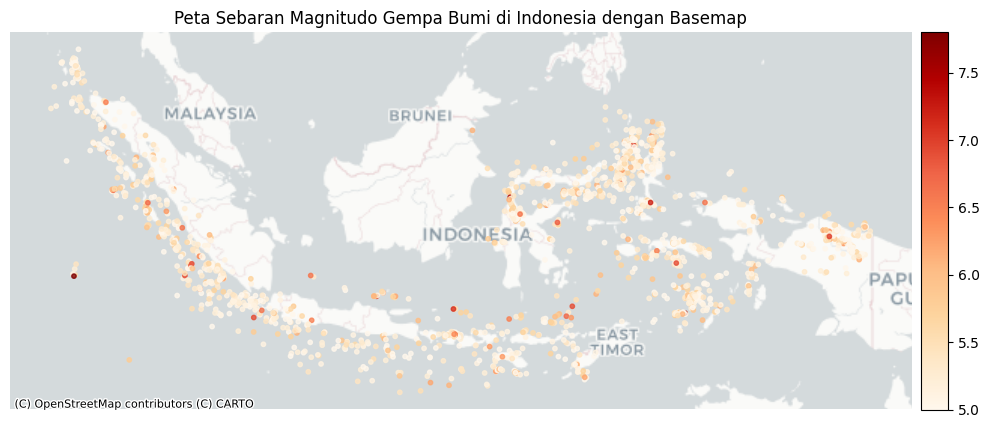

In [55]:
lat_jitter = df_id["Latitude"].values + np.random.uniform(-0.05, 0.05, len(df_id))
lon_jitter = df_id["Longitude"].values + np.random.uniform(-0.05, 0.05, len(df_id))

gdf_mag = gpd.GeoDataFrame(
    df_id.copy(),
    geometry=gpd.points_from_xy(lon_jitter, lat_jitter),
    crs="EPSG:4326"
)

gdf_mag = gdf_mag.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 8))

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)

# Plot titik gempa dengan warna berdasarkan magnitudo
gdf_mag.plot(
    ax=ax,
    column="Earthquake Magnitude",
    cmap="OrRd",
    legend=True,
    cax=cax,
    markersize=10,
    alpha=0.8
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

ax.set_title("Peta Sebaran Magnitudo Gempa Bumi di Indonesia dengan Basemap")
ax.axis("off")

plt.tight_layout()
plt.show()

##Visualisasi Peta + Grafik Bar (Top 5 Magnitudo Terbesar & Terkecil)

In [56]:
# Top 5 gempa terbesar dan terkecil berdasarkan magnitudo
top5_big = df_id.nlargest(5, "Earthquake Magnitude")
top5_small = df_id.nsmallest(5, "Earthquake Magnitude")

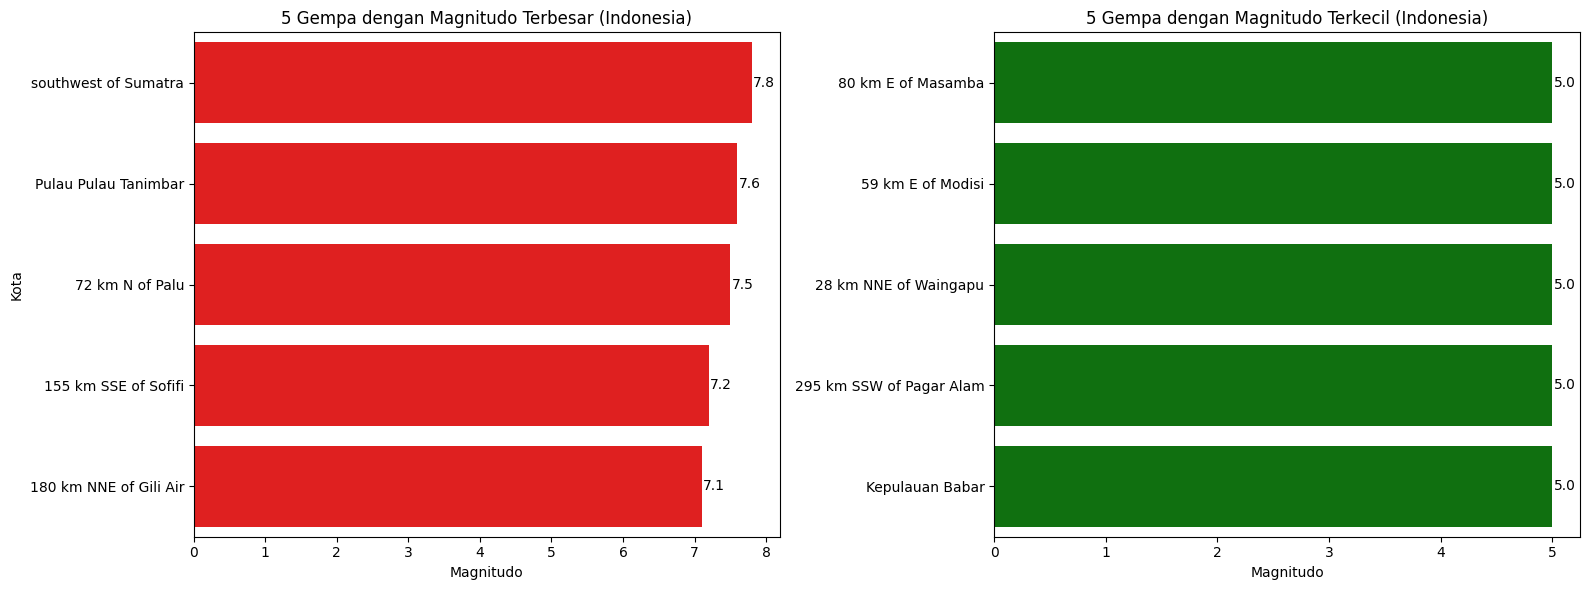

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar 5 gempa terbesar
sns.barplot(
    data=top5_big,
    x="Earthquake Magnitude",
    y="City",
    ax=axes[0],
    color="red"
)
axes[0].set_title("5 Gempa dengan Magnitudo Terbesar (Indonesia)")
axes[0].set_xlabel("Magnitudo")
axes[0].set_ylabel("Kota")

for i, v in enumerate(top5_big["Earthquake Magnitude"]):
    axes[0].text(v + 0.02, i, f"{v:.1f}", va="center")

# Bar 5 gempa terkecil
sns.barplot(
    data=top5_small,
    x="Earthquake Magnitude",
    y="City",
    ax=axes[1],
    color="green"
)
axes[1].set_title("5 Gempa dengan Magnitudo Terkecil (Indonesia)")
axes[1].set_xlabel("Magnitudo")
axes[1].set_ylabel("")

for i, v in enumerate(top5_small["Earthquake Magnitude"]):
    axes[1].text(v + 0.02, i, f"{v:.1f}", va="center")

plt.tight_layout()
plt.show()

#Uji Normalitas

In [58]:
# Statistika deskriptif beberapa kolom numerik
numeric_cols = ["Earthquake Magnitude", "Depth (km)", "Impact Score",
                "Latitude", "Longitude"]

df_id[numeric_cols].describe()

,Earthquake Magnitude,Depth (km),Impact Score,Latitude,Longitude
count,1743.000000,1743.000000,1743.000000,1743.000000,1743.000000
mean,5.291452,55.384232,437.931153,-2.513452,118.856397
std,0.373338,90.574911,90.905351,4.342896,13.269972
min,5.000000,4.000000,385.000000,-11.626300,92.971800
25%,5.000000,10.000000,385.000000,-6.099050,105.375050
50%,5.200000,31.260000,416.000000,-2.598000,123.450300
75%,5.400000,58.385000,449.000000,1.016000,128.152150
max,7.800000,652.530000,2033.000000,8.351000,140.893500


In [59]:
normality_df = df_id[numeric_cols].copy()
normality_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1743 entries, 4 to 16939
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Earthquake Magnitude  1743 non-null   float64
 1   Depth (km)            1743 non-null   float64
 2   Impact Score          1743 non-null   int64  
 3   Latitude              1743 non-null   float64
 4   Longitude             1743 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 146.2 KB


In [60]:
stat, p = shapiro(normality_df)
print("Statistik Shapiro:", stat)
print("p-value:", p)

if p > 0.05:
    print("Data berdistribusi normal (gagal tolak H0)")
else:
    print("Data TIDAK berdistribusi normal (tolak H0)")

Statistik Shapiro: 0.7253478436641407
p-value: 2.6597326143863534e-80
Data TIDAK berdistribusi normal (tolak H0)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning:

scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8715.



#Analisis Matriks Korelasi (Spearman)

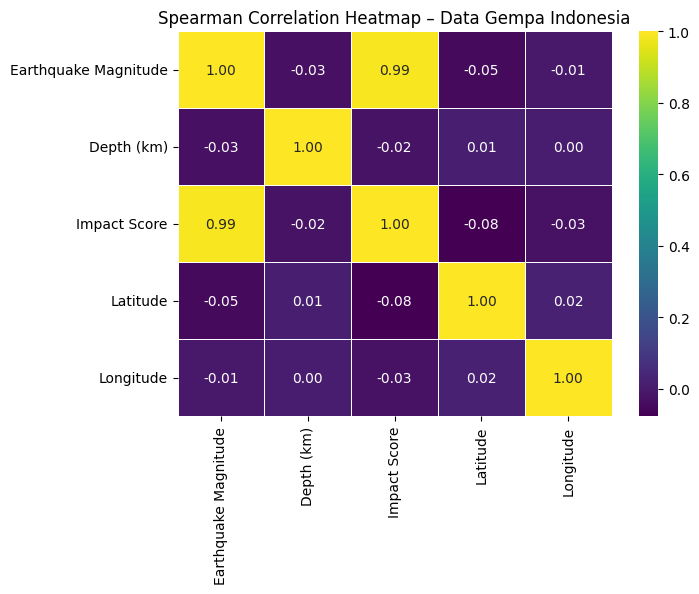

In [61]:
corr_spearman = normality_df.corr(method="spearman")

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_spearman,
    annot=True,
    cmap="viridis",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Spearman Correlation Heatmap – Data Gempa Indonesia")
plt.show()

#Normalisasi Data

##Pemilihan Kolom untuk Normalisasi

In [62]:
features_for_cluster = ["Earthquake Magnitude", "Depth (km)",
                        "Impact Score", "Latitude", "Longitude"]

normalisasi_df = df_id[features_for_cluster].copy()
normalisasi_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1743 entries, 4 to 16939
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Earthquake Magnitude  1743 non-null   float64
 1   Depth (km)            1743 non-null   float64
 2   Impact Score          1743 non-null   int64  
 3   Latitude              1743 non-null   float64
 4   Longitude             1743 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 146.2 KB


##Proses Normalisasi dengan RobustScaler

In [63]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(normalisasi_df)

X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_cluster)
X_scaled_df.describe().T


,count,mean,std,min,25%,50%,75%,max
Earthquake Magnitude,1743.0,0.228629,0.933346,-0.500000,-0.500000,0.0,0.500000,6.500000
Depth (km),1743.0,0.498589,1.871963,-0.563398,-0.439392,0.0,0.560608,12.840136
Impact Score,1743.0,0.342674,1.420396,-0.484375,-0.484375,0.0,0.515625,25.265625
Latitude,1743.0,0.011883,0.610382,-1.268902,-0.492063,0.0,0.507937,1.538851
Longitude,1743.0,-0.201690,0.582601,-1.338120,-0.793571,0.0,0.206429,0.765822


#Menentukan Parameter ε dengan K-Distance Graph

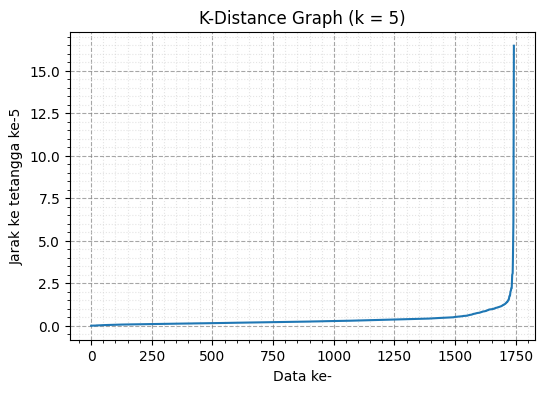

In [64]:
k = 5  # min_samples awal
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled_df)
distances, indices = neighbors_fit.kneighbors(X_scaled_df)

k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(6, 4))
plt.plot(k_distances)
plt.title(f"K-Distance Graph (k = {k})")
plt.xlabel("Data ke-")
plt.ylabel(f"Jarak ke tetangga ke-{k}")
plt.grid(True, alpha=0.3)
plt.grid(which='major', color='gray', linestyle='--', alpha=0.7)
plt.grid(which='minor', color='lightgray', linestyle=':', alpha=0.6)
plt.minorticks_on()
plt.show()

In [65]:
eps_value = 1.8
min_samples_value = 5  # sama dengan k

#Clustering dengan DBSCAN

In [66]:
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
cluster_labels = dbscan.fit_predict(X_scaled_df)

df_id["Cluster"] = cluster_labels

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)

print("Jumlah cluster (tanpa noise):", n_clusters)
print("Jumlah noise:", n_noise)
df_id["Cluster"].value_counts()

Jumlah cluster (tanpa noise): 2
Jumlah noise: 9


,count
Cluster,
0,1699
1,35
-1,9


#Evaluasi Kualitas Clustering (Silhouette Score)

In [67]:
if n_clusters > 1:
    sil = silhouette_score(X_scaled_df, cluster_labels)
    print("Silhouette Score:", sil)
else:
    print("Silhouette Score tidak bisa dihitung (cluster < 2).")


Silhouette Score: 0.7895419835702762


#Visualisasi Hasil Clustering dengan PCA (2D)

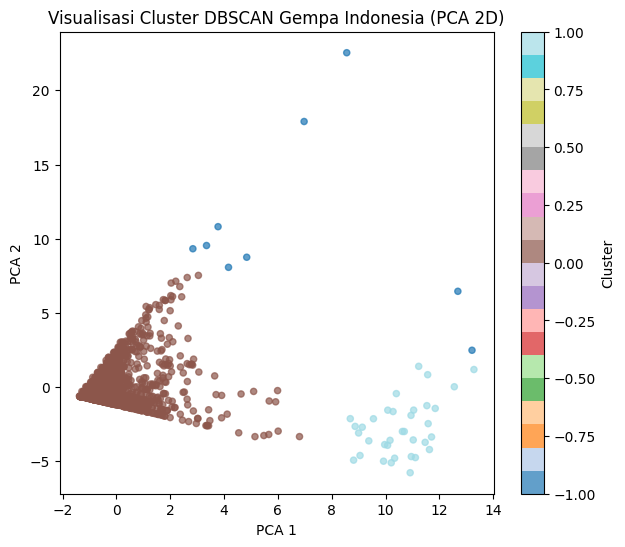

In [68]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_df)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    cmap="tab20",
    s=20,
    alpha=0.7
)
plt.title("Visualisasi Cluster DBSCAN Gempa Indonesia (PCA 2D)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

#Pengelompokan Kualitatif Cluster

In [69]:
def klasifikasi_cluster(label):
    if label == -1:
        return "Noise"
    elif label == 0:
        return "Cluster Utama"
    else:
        return "Cluster Lain"

df_id["Klasifikasi_DBSCAN"] = df_id["Cluster"].apply(klasifikasi_cluster)
df_id[["Date", "City", "Earthquake Magnitude", "Depth (km)",
       "Klasifikasi_DBSCAN"]].head()

,Date,City,Earthquake Magnitude,Depth (km),Klasifikasi_DBSCAN
4,2025-03-14,229 km N of Palu,5.4,26.072,Cluster Utama
27,2025-03-07,69 km W of Banda Aceh,5.4,73.061,Cluster Utama
29,2025-03-07,80 km E of Masamba,5.0,10.000,Cluster Utama
43,2025-03-02,61 km ESE of Masohi,5.3,41.306,Cluster Utama
52,2025-02-28,231 km W of Tual,5.5,126.000,Cluster Utama


#Analisis Lanjutan per Cluster (Cluster Summary)

In [70]:
cluster_summary = (
    df_id
    .groupby("Klasifikasi_DBSCAN")[["Earthquake Magnitude", "Depth (km)", "Impact Score"]]
    .mean(numeric_only=True)
    .round(2)
)

cluster_summary


,Earthquake Magnitude,Depth (km),Impact Score
Klasifikasi_DBSCAN,,,
Cluster Lain,5.72,577.78,511.83
Cluster Utama,5.27,44.09,432.35
Noise,6.99,155.66,1203.78


#Visualisasi Interaktif Persebaran Cluster (Plotly)

In [71]:
fig_map = px.scatter_mapbox(
    df_id,
    lat="Latitude",
    lon="Longitude",
    color="Klasifikasi_DBSCAN",
    hover_name="City",
    hover_data=["Date", "Earthquake Magnitude", "Depth (km)"],
    zoom=3,
    height=500,
    title="Peta Interaktif Cluster Gempa Bumi di Indonesia"
)

fig_map.update_layout(mapbox_style="open-street-map")
fig_map.show()
